# Model Training

This notebook loads the cleaned dataset produced by `EDA.ipynb` (`df_clean.pkl`) and trains/compares regression models to predict house price.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


## 0. Load Cleaned Data

Make sure `df_clean.pkl` exists in this same folder (created by running `EDA.ipynb` first).

In [31]:
df_clean = pd.read_pickle("df_clean.pkl")
print("Loaded df_clean with shape:", df_clean.shape)
df_clean.head()


Loaded df_clean with shape: (173129, 28)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,Super Area,total_price,carpet_sqft,super_sqft,area_sqft,BHK,floor_num,total_floors,car_parking_num,price_per_sqft
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,4200000.0,500.0,NaN,500.0,1.0,10.0,11.0,NaN,8400.000000
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,NaN,9800000.0,473.0,NaN,473.0,2.0,3.0,22.0,1.0,20718.816068
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,NaN,14000000.0,779.0,NaN,779.0,2.0,10.0,29.0,1.0,17971.758665
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,2500000.0,530.0,NaN,530.0,1.0,1.0,3.0,NaN,4716.981132
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,NaN,16000000.0,635.0,NaN,635.0,2.0,20.0,42.0,1.0,25196.850394


## 7. Modeling

**Target:** `log(total_price)` (to tame the right-skew seen above).

**Features:** numeric (`area_sqft`, `BHK`, `floor_num`, `total_floors`, `Bathroom`, `Balcony`,
`car_parking_num`) + categorical (`location` grouped to top-30 + "other", `Status`,
`Transaction`, `Furnishing`, `facing`).

We compare three models of increasing complexity:
- **Linear Regression** — simple baseline, assumes additive/linear effects.
- **Random Forest** — captures non-linearities and interactions automatically.
- **LightGBM (Gradient Boosting)** — usually the strongest off-the-shelf model for this kind
  of structured/tabular data with mixed numeric + high-cardinality categorical features.


In [32]:
# Group rare locations into 'other' to keep one-hot encoding manageable
top_loc = df_clean['location'].value_counts().head(30).index
df_clean['location_grp'] = np.where(df_clean['location'].isin(top_loc), df_clean['location'], 'other')

df_clean['log_price'] = np.log1p(df_clean['total_price'])

num_features = ['area_sqft','BHK','floor_num','total_floors','Bathroom','Balcony','car_parking_num']
cat_features = ['location_grp','Status','Transaction','Furnishing','facing']

X = df_clean[num_features + cat_features]
y = df_clean['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(138503, 12) (34626, 12)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import numpy as np

# 1. Define Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_features)
])

# 2. Evaluation Helper Function
def evaluate_model(name, model):
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)

    r2 = r2_score(y_test, pred_log)
    rmse_log = mean_squared_error(y_test, pred_log) ** 0.5
    mae_rupees = mean_absolute_error(np.expm1(y_test), np.expm1(pred_log))

    print(f"{name:18s} | R2: {r2:.4f} | RMSE(log price): {rmse_log:.4f} | MAE: Rs {mae_rupees:,.0f}")
    return pipe, r2, rmse_log, mae_rupees

results = {}

# 3. Train & Evaluate all 6 models
# 1. Linear Regression Baseline
results['Linear Regression'] = evaluate_model('Linear Regression', LinearRegression())

# 2. Random Forest
results['Random Forest']     = evaluate_model('Random Forest', RandomForestRegressor(
    n_estimators=60, max_depth=12, n_jobs=-1, random_state=42))

# 3. Extra Trees
results['Extra Trees']       = evaluate_model('Extra Trees', ExtraTreesRegressor(
    n_estimators=60, max_depth=12, n_jobs=-1, random_state=42))

# 4. LightGBM
results['LightGBM']          = evaluate_model('LightGBM', lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=42, verbosity=-1))

# 5. XGBoost
results['XGBoost']           = evaluate_model('XGBoost', xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0))

# 6. CatBoost
results['CatBoost']          = evaluate_model('CatBoost', CatBoostRegressor(
    iterations=300, learning_rate=0.05, depth=6, random_state=42, verbose=0))

Linear Regression  | R2: 0.7270 | RMSE(log price): 0.4195 | MAE: Rs 3,967,296
Random Forest      | R2: 0.9006 | RMSE(log price): 0.2532 | MAE: Rs 1,359,262
Extra Trees        | R2: 0.8862 | RMSE(log price): 0.2708 | MAE: Rs 1,629,972


e:\DevelopersHub\House Price Prediction\venvr\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM           | R2: 0.9256 | RMSE(log price): 0.2190 | MAE: Rs 1,267,883
XGBoost            | R2: 0.9153 | RMSE(log price): 0.2336 | MAE: Rs 1,542,769
CatBoost           | R2: 0.8930 | RMSE(log price): 0.2626 | MAE: Rs 2,029,151


In [34]:
comparison = pd.DataFrame({
    name: {'R2': r2, 'RMSE (log price)': rmse, 'MAE (Rs)': mae}
    for name, (_, r2, rmse, mae) in results.items()
}).T
comparison


,R2,RMSE (log price),MAE (Rs)
Linear Regression,0.727024,0.419468,3.967296e+06
Random Forest,0.900554,0.253180,1.359262e+06
Extra Trees,0.886199,0.270838,1.629972e+06
LightGBM,0.925568,0.219037,1.267883e+06
XGBoost,0.915315,0.233637,1.542769e+06
CatBoost,0.893037,0.262575,2.029151e+06


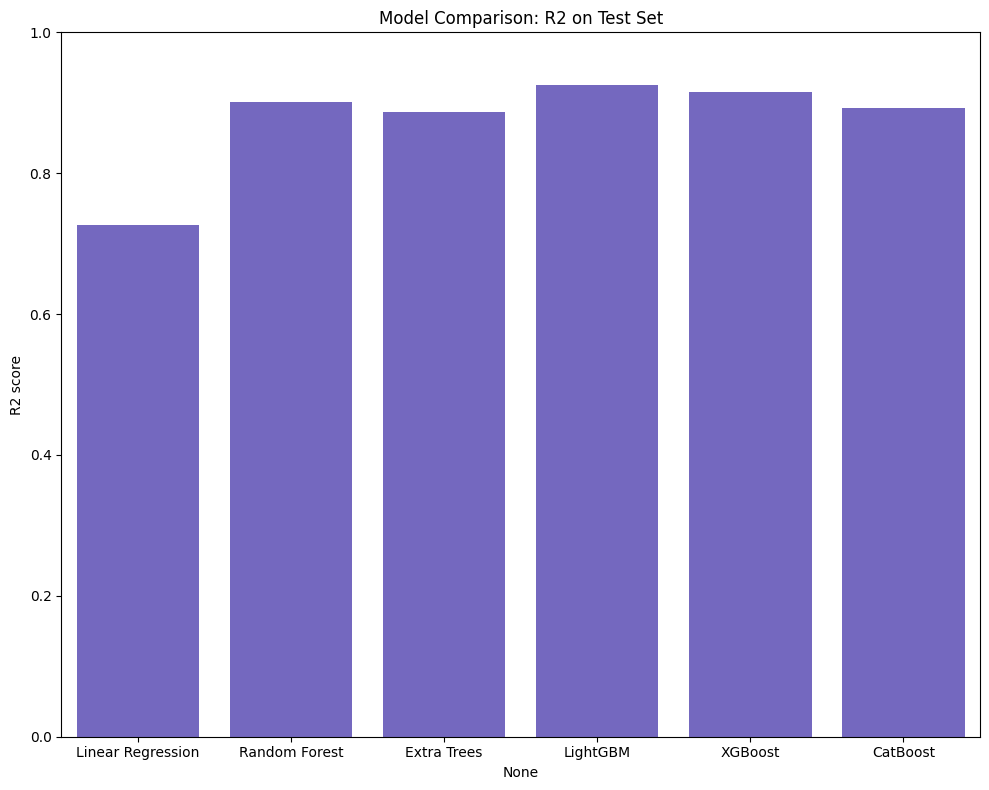

In [35]:
plt.figure(figsize=(10,8))
sns.barplot(x=comparison.index, y=comparison['R2'], color='slateblue')
plt.title('Model Comparison: R2 on Test Set')
plt.ylabel('R2 score')
plt.ylim(0,1)
plt.tight_layout()
plt.show()


## 8. Feature Importance (LightGBM)


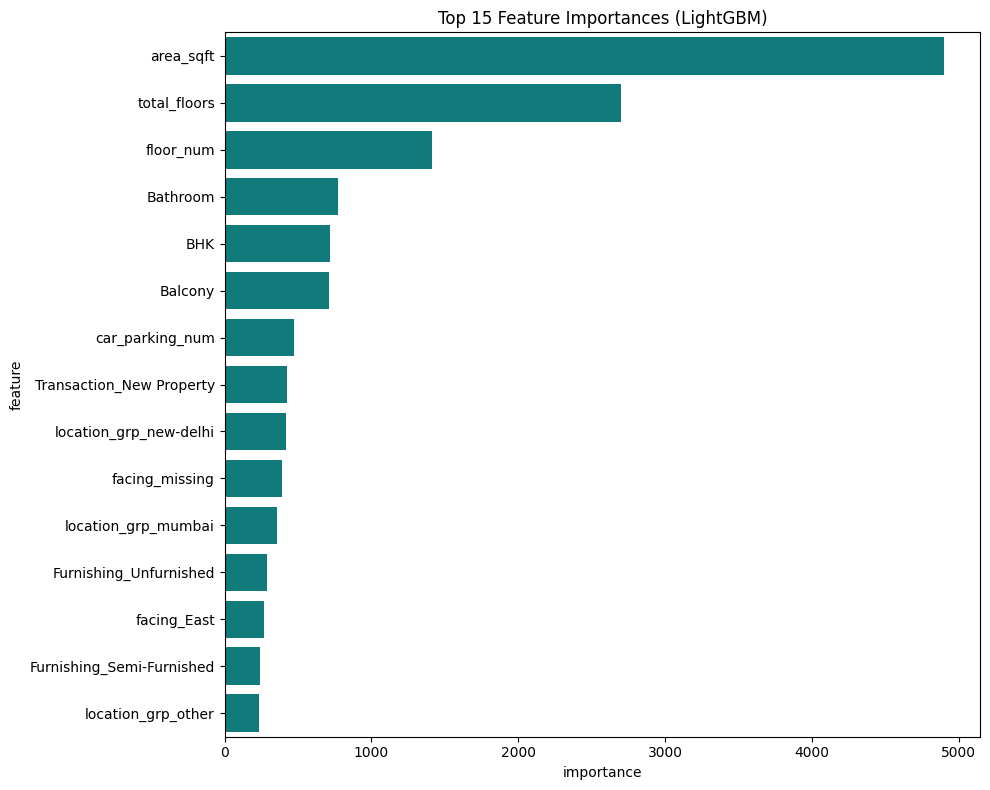

In [36]:
best_pipe = results['LightGBM'][0]
feature_names = (num_features +
    list(best_pipe.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(cat_features)))

importances = best_pipe.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(data=imp_df, x='importance', y='feature', color='darkcyan')
plt.title('Top 15 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()
